# Cryptocurrency Fraud Detection & Risk Network Analysis

Using graph analysis and blockchain transaction networks to identify suspicious cryptocurrency activities.

## 1. Background

Cryptocurrency transactions are highly interconnected.

Traditional fraud detection methods often rely on transaction-level features, but network relationships may reveal deeper criminal structures.

This project explores:

--illicit transaction patterns
--risk propagation
--suspicious unknown wallets
--community-based fraud clustering

using the Elliptic Bitcoin Dataset.

## 2. Dataset

This project uses the Elliptic Bitcoin Dataset, which contains:

--transaction labels
--transaction features
--transaction network connections

In [101]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# Transaction labels
classes = pd.read_csv("elliptic_txs_classes.csv")

# Transaction features
features = pd.read_csv(
    "elliptic_txs_features.csv",
    header=None
)

features.columns = (
    ["txId", "time_step"] +
    [f"feature_{i}" for i in range(1,166)]
)

# Transaction network
edges = pd.read_csv("elliptic_txs_edgelist.csv")

## 3. Data Merge

In [102]:
#1. Merge transaction labels and features
merged = pd.merge(classes, features, on="txId")
merged.head()

#2. Add class labels to network edges
edges_with_class = edges.merge(
    classes,
    left_on = "txId1",
    right_on = "txId"
)
edges_with_class.head()

#3. Add second node labels
edges_full = edges.merge(
     classes,
     left_on="txId1",
     right_on="txId"
).rename(columns={"class":"class1"})
edges_full = edges_full.merge(
    classes,
    left_on= "txId2",
    right_on="txId"
).rename(columns={"class":"class2"})

#4. Clean redundant columns
edges_full = edges_full.drop(columns=["txId_x","txId_y"])
edges_full.head()

,txId1,txId2,class1,class2
0,230425980,5530458,unknown,unknown
1,232022460,232438397,unknown,2
2,230460314,230459870,unknown,unknown
3,230333930,230595899,unknown,unknown
4,232013274,232029206,unknown,2


## 4. Temporal Analysis of Illicit Transactions

In [103]:
merged.groupby("time_step")["class"].value_counts()

time_step  class  
1          unknown    5733
           2          2130
           1            17
2          unknown    3427
           2          1099
                      ... 
48         2           435
           1            36
49         unknown    1978
           2           420
           1            56
Name: count, Length: 147, dtype: int64

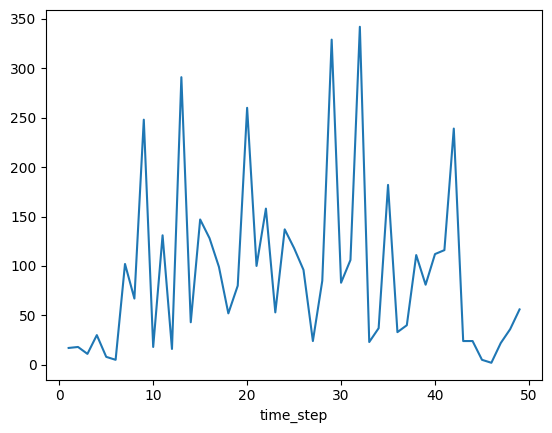

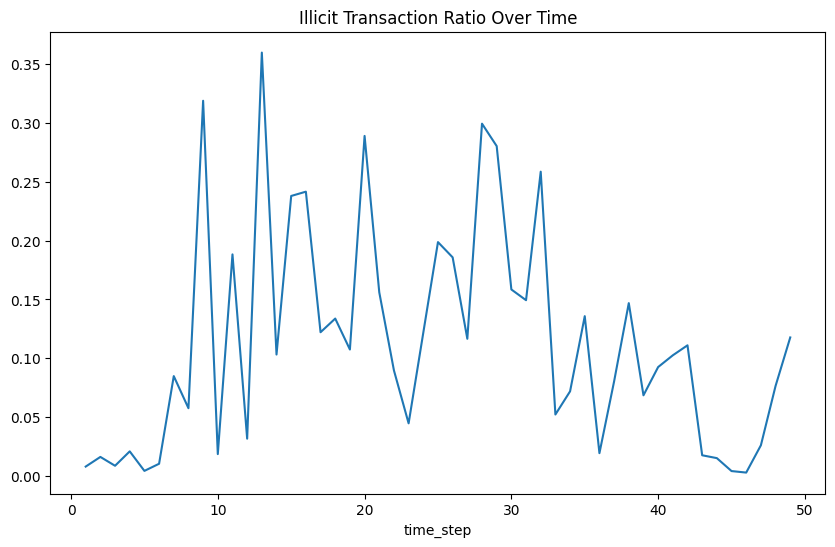

In [141]:
illegal_tx = merged[merged["class"] == "1"]
illegal_count = illegal_tx.groupby("time_step").size()
illegal_count.plot()
known_tx = merged[merged["class"] != "unknown"]

illegal_ratio = (
    risk_ratio.loc[(slice(None), "1")]
)

plt.figure(figsize=(10,6))

illegal_ratio.plot()

plt.title("Illicit Transaction Ratio Over Time")

plt.savefig(
    "images/illicit_ratio_over_time.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Finding

Temporal fluctuations in illicit transactions are observable, but transaction timing alone appears insufficient to reliably distinguish illicit activity from legitimate behavior.

## 5. Feature Analysis

### 5.1 High-risk Unknown Feature Comparison

In [105]:
top_unknown_features = features[
    features["txId"].isin(top_unknown)
    ]
top_unknown_features.head()

,txId,time_step,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,...,feature_156,feature_157,feature_158,feature_159,feature_160,feature_161,feature_162,feature_163,feature_164,feature_165
87316,65263113,20,0.148024,-0.002007,1.018602,-0.121970,0.531776,-0.113002,-0.061584,0.164797,...,1.346544,0.639043,0.096065,0.118352,-0.098889,0.585366,0.375300,0.086257,-0.163978,-0.144909
127576,355092392,32,-0.160476,0.776358,1.573595,-0.121970,0.194326,-0.113002,-0.061584,-0.150825,...,-0.205002,-0.480257,-0.351528,-0.444906,-0.098889,-0.087490,-0.098469,-0.152904,-0.939507,-0.939125
151576,26532670,38,-0.084497,1.524329,1.573595,-0.121970,1.147127,-0.113002,-0.061584,-0.073069,...,1.684292,1.017164,0.358301,0.329661,-0.098889,1.488915,0.578091,0.009465,-0.024814,0.039885
151666,2842440,38,-0.100091,1.808034,1.573595,-0.121970,1.563978,-0.113002,-0.061584,-0.089016,...,1.100422,0.490803,0.397311,0.340048,-0.098889,1.488915,0.488742,-0.029236,-0.157087,-0.026643
151713,4732368,38,0.129054,2.290399,1.573595,0.103143,1.722778,0.138585,-0.061584,-0.154077,...,0.839221,0.273863,0.275101,0.296110,-0.098889,1.488915,0.465527,-0.017057,-0.126847,-0.032935


In [106]:
illegal_features = merged[
    merged["class"] == "1"
    ]
illegal_features.iloc[:,2:].mean().head(10)

time_step    25.078768
feature_1    -0.165745
feature_2    -0.030698
feature_3     0.212061
feature_4     0.010803
feature_5    -0.056724
feature_6     0.033743
feature_7    -0.059910
feature_8    -0.157009
feature_9    -0.162628
dtype: float64

In [107]:
top_unknown_features.iloc[:,2:].mean().head(10)

feature_1    -0.004902
feature_2     1.452233
feature_3     1.518095
feature_4    -0.084451
feature_5     1.071697
feature_6    -0.071071
feature_7    -0.061584
feature_8    -0.028549
feature_9    -0.017849
feature_10    0.086208
dtype: float64

#### key finding
High-risk unknown transactions exhibit partially similar feature patterns to known illicit transactions, although differences remain substantial.

### 5.2 Correlation Analysis

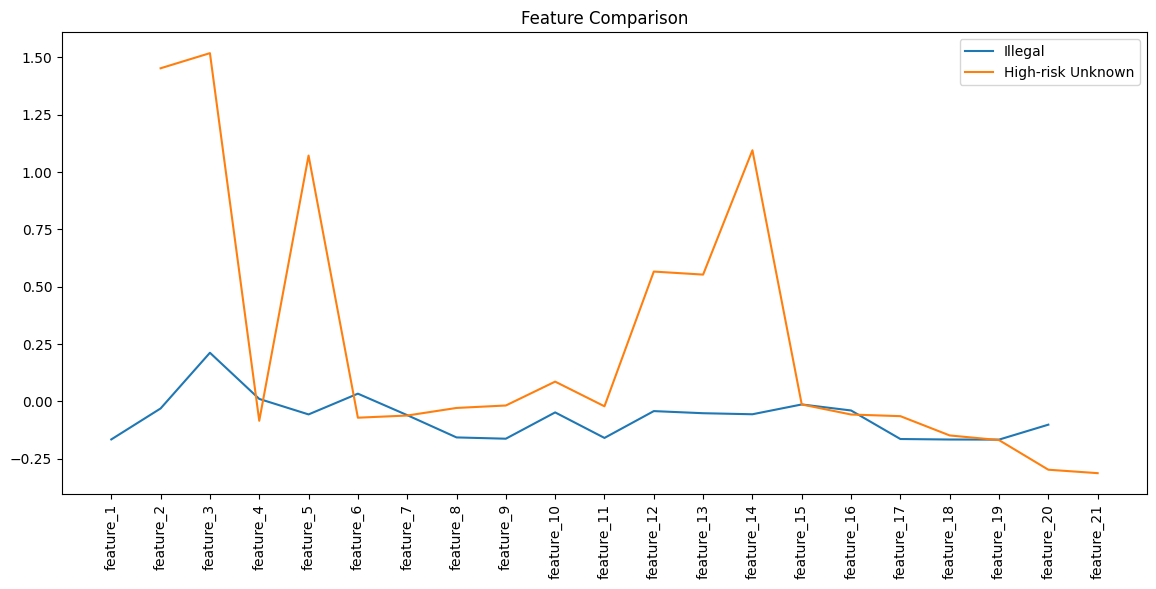

In [142]:
illegal_mean = illegal_features.iloc[:,3:].mean()
unknown_mean = top_unknown_features.iloc[:,3:].mean()

plt.figure(figsize=(14,6))

plt.plot(
    illegal_mean.index[:20],
    illegal_mean.values[:20],
    label="Illegal"
)

plt.plot(
    unknown_mean.index[:20],
    unknown_mean.values[:20],
    label="High-risk Unknown"
)

plt.legend()

plt.xticks(rotation=90)

plt.title("Feature Comparison")

plt.savefig(
    "images/feature_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [109]:
known_data = merged[
    merged["class"] != "unknown"
    ].copy()
known_data["class"] = known_data["class"].astype(int)
correlations = known_data.corr()["class"]
correlations.sort_values().head(10)
correlations.sort_values().tail(10)

feature_114    0.137636
feature_54     0.142125
feature_52     0.171799
feature_91     0.185804
feature_150    0.187232
feature_90     0.221294
feature_55     0.227146
feature_89     0.227629
feature_53     0.261472
class          1.000000
Name: class, dtype: float64

#### key finding
Most individual transaction features show weak linear correlation with illicit labels, suggesting that illicit behavior may not be identifiable through isolated transactional characteristics alone.

### Finding
Individual transaction features show relatively weak correlation with illicit labels. 
Behavioral transaction features alone appear insufficient for robust illicit transaction detection. Network structure and relational connectivity provide substantially stronger signals for identifying suspicious activity.

## 6. Network Analysis

### 6.1 Risk Propagation

In [110]:
edges_full[["class1","class2"]].value_counts()

class1   class2 
unknown  unknown    131778
         2           45386
2        2           33930
         unknown     15116
unknown  1            3993
1        unknown      1458
         1             998
         2             915
2        1             781
Name: count, dtype: int64

In [111]:
suspicious_neighbors = edges_full[
    ((edges_full["class1"] == "1") & (edges_full["class2"] == "unknown")) |
    ((edges_full["class2"] == "1") & (edges_full["class1"] == "unknown"))
]
suspicious_neighbors.head()

,txId1,txId2,class1,class2
432,232947878,232947876,1,unknown
2911,16742787,39617080,1,unknown
5589,232014511,3317903,1,unknown
5952,232673081,62195631,unknown,1
6607,131942180,17387772,unknown,1


In [112]:
unknown_risk = suspicious_neighbors[
    suspicious_neighbors["class1"] == "unknown"
    ]["txId1"].value_counts()

unknown_risk.head(10)

txId1
355092392    8
8695835      7
4732368      7
26532670     6
2842440      6
12776876     6
65263113     5
17124347     5
10773646     5
8373032      5
Name: count, dtype: int64

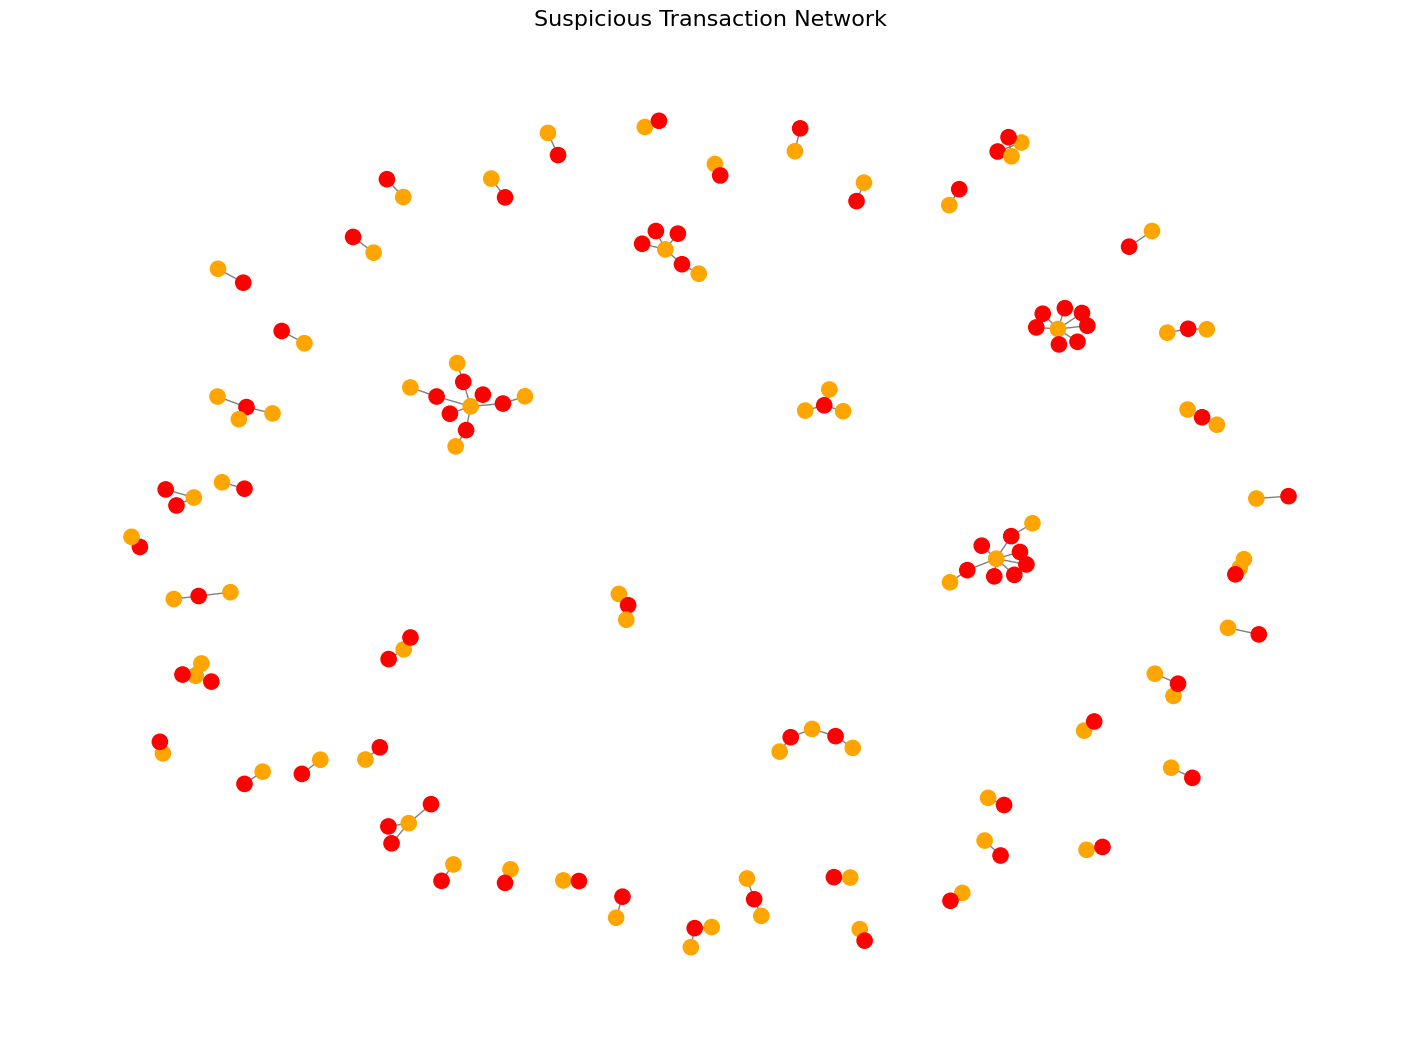

In [143]:
import matplotlib.pyplot as plt

sample_edges = suspicious_neighbors.head(100)

G = nx.from_pandas_edgelist(
    sample_edges,
    source="txId1",
    target="txId2"
)

plt.figure(figsize=(14,10))

# illegal node set
illegal_nodes = set(
    sample_edges[
        sample_edges["class1"] == "1"
    ]["txId1"]
).union(
    set(
        sample_edges[
            sample_edges["class2"] == "1"
        ]["txId2"]
    )
)

# node colors
node_colors = []

for node in G.nodes():

    if node in illegal_nodes:
        node_colors.append("red")

    else:
        node_colors.append("orange")

# better layout
pos = nx.spring_layout(
    G,
    seed=42
)

nx.draw(
    G,
    pos,
    with_labels=False,
    node_color=node_colors,
    node_size=120,
    edge_color="gray"
)

plt.title(
    "Suspicious Transaction Network",
    fontsize=16
)

plt.savefig(
    "images/suspicious_network.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### key finding
Illegal transactions will spread risks to unknown transactions.

### 6.2 Network Structure Analysis

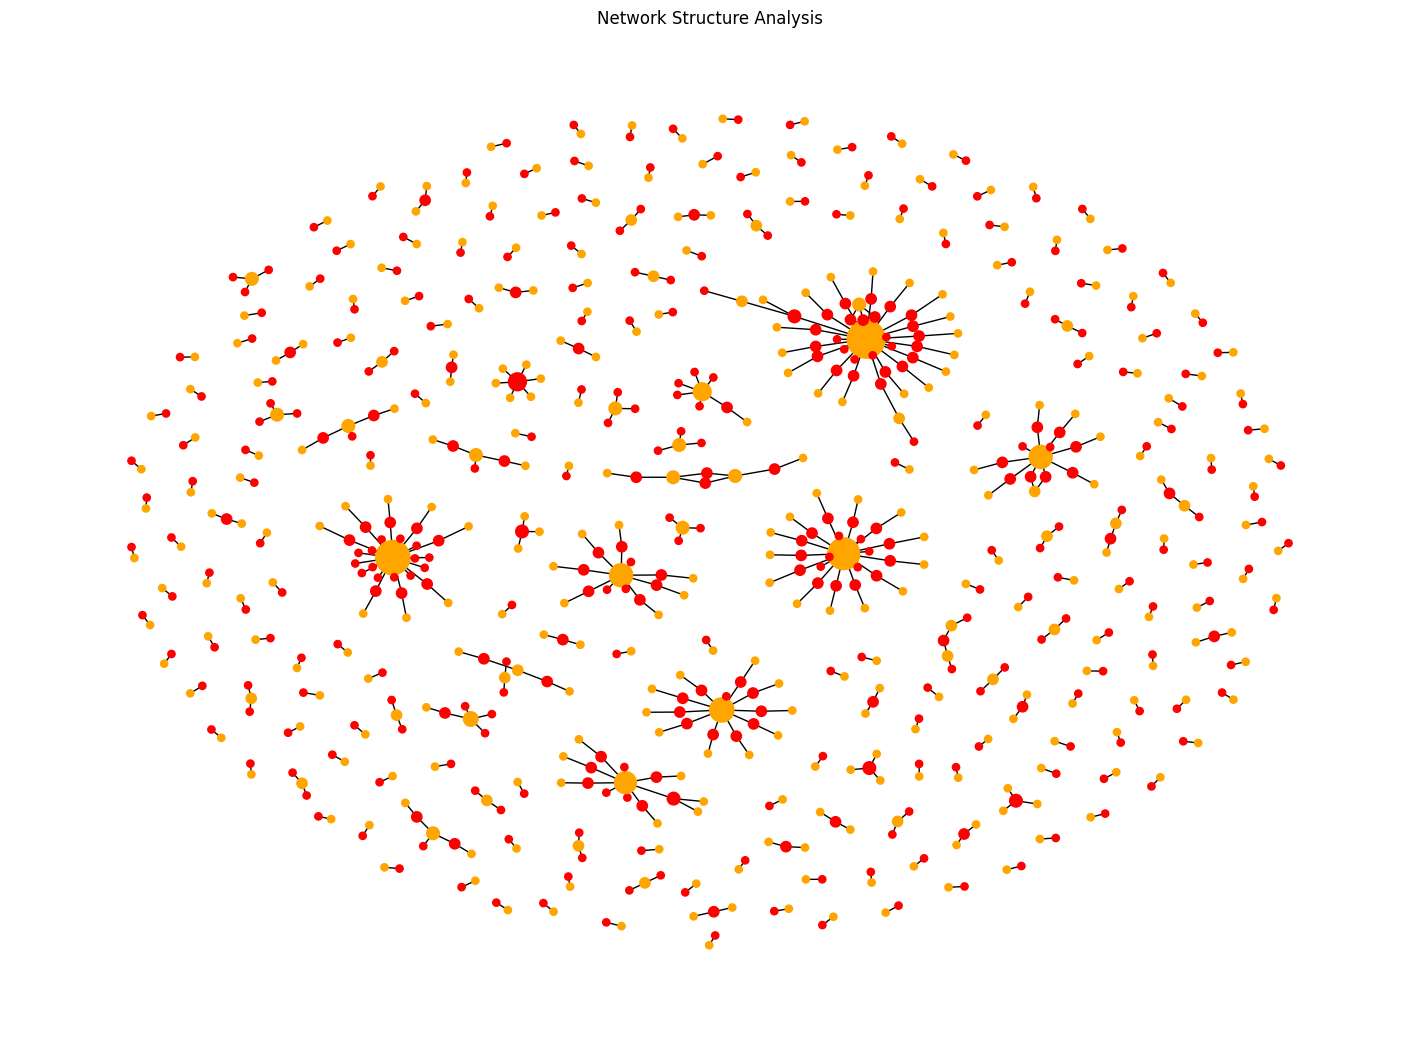

In [144]:
plt.figure(figsize=(14,10))

sample_edges = suspicious_neighbors.head(500)

G = nx.from_pandas_edgelist(
    sample_edges,
    source="txId1",
    target="txId2"
)

centrality = nx.degree_centrality(G)
# step1 illegal nodes
illegal_nodes = set(
    sample_edges[
        sample_edges["class1"] == "1"
    ]["txId1"]
).union(

    set(
        sample_edges[
            sample_edges["class2"] == "1"
        ]["txId2"]
    )
)

# step2 color
node_colors = []

for node in G.nodes():

    if node in illegal_nodes:
        node_colors.append("red")

    else:
        node_colors.append("orange")

# step3 scale
node_sizes = [
    centrality[node] * 20000
    for node in G.nodes()
]

nx.draw(
    G,
    with_labels=False,
    node_color=node_colors,
    node_size=node_sizes
)

plt.title("Network Structure Analysis")

plt.savefig(
    "images/network_structure_analysis.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### key finding
The risk network exhibits a distinctly centralized structure. 
A few core nodes have an abnormally high degree of connectivity within the network.

### 6.3 Community Detection

In [128]:
from networkx.algorithms.community import greedy_modularity_communities
communities = greedy_modularity_communities(G)
len(communities)

231

In [129]:
largest_community = list(communities[0])
largest_community[:10]

[142973061,
 179039621,
 179039624,
 179039625,
 179039626,
 179039627,
 179039628,
 179039629,
 179039630,
 179039631]

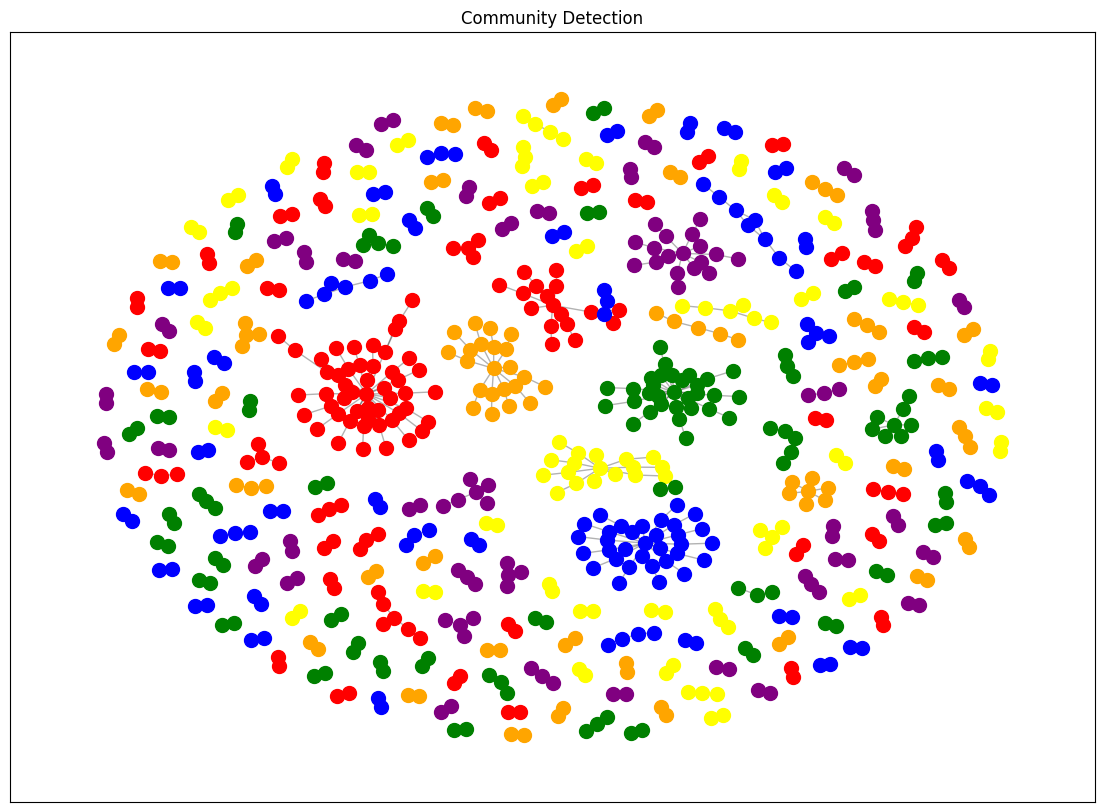

In [145]:
import matplotlib.pyplot as plt
plt.figure(figsize=(14,10))

pos = nx.spring_layout(G, seed=42)

colors = [
    "red",
    "blue",
    "green",
    "orange",
    "purple",
    "yellow"
]
for i, community in enumerate(communities):
    nx.draw_networkx_nodes(
        G,
        pos,
        nodelist=list(community),
        node_color=colors[i % len(colors)],
        node_size=100
    )

nx.draw_networkx_edges(
    G,
    pos,
    alpha=0.3
)
plt.title("Community Detection")
plt.savefig(
    "images/community——datection.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [131]:
community_map = {}
for i, community in enumerate(communities):
    for node in community:
        community_map[node] = i

merged["community"] = merged["txId"].map(community_map)
community_risk = (
    merged.groupby("community")["class"]
    .value_counts(normalize=True)
)
community_risk
community_risk.loc[(slice(None),"1")]
community_risk.loc[(slice(None),"1")]\
.sort_values(ascending=False)

C:\Users\谭芃\AppData\Local\Temp\ipykernel_8628\975835482.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  merged["community"] = merged["txId"].map(community_map)


community
22.0    0.750000
24.0    0.750000
19.0    0.750000
16.0    0.750000
8.0     0.750000
          ...   
26.0    0.333333
18.0    0.250000
17.0    0.250000
21.0    0.250000
9.0     0.142857
Name: proportion, Length: 231, dtype: float64

#### key finding
--Illicit cryptocurrency transactions exhibit strong community clustering rather than random distribution.
--Certain transaction communities are significantly more illicit-dense than the global average.

### 6.4 Risk scoring

In [132]:
community_size = merged.groupby("community").size()
community_size.sort_values(ascending=False).head(10)

community
0.0    50
1.0    33
2.0    31
3.0    22
4.0    18
5.0    18
6.0    17
7.0     8
8.0     8
9.0     7
dtype: int64

In [133]:
illegal_ratio = (
    community_risk.loc[(slice(None),"1")]
    .reset_index()
)
illegal_ratio.columns = [
    "community",
    "illegal_ratio"
]
illegal_ratio
community_summary = pd.merge(
    illegal_ratio,
    community_size.reset_index(),
    on="community"
)
community_summary.columns = [
    "community",
    "illegal_ratio",
    "size"
]
community_summary

,community,illegal_ratio,size
0,0.0,0.580000,50
1,1.0,0.575758,33
2,2.0,0.709677,31
3,3.0,0.500000,22
4,4.0,0.555556,18
...,...,...,...
226,226.0,0.500000,2
227,227.0,0.500000,2
228,228.0,0.500000,2
229,229.0,0.500000,2


In [134]:
community_summary[
    community_summary["size"] >= 10
].sort_values(
    by="illegal_ratio",
    ascending=False
)

,community,illegal_ratio,size
2,2.0,0.709677,31
0,0.0,0.580000,50
1,1.0,0.575758,33
4,4.0,0.555556,18
5,5.0,0.555556,18
6,6.0,0.529412,17
3,3.0,0.500000,22


In [135]:
community_summary[
    community_summary["size"] >= 10
    ].sort_values(
        by="illegal_ratio",
        ascending=False
    ).head(10)

,community,illegal_ratio,size
2,2.0,0.709677,31
0,0.0,0.580000,50
1,1.0,0.575758,33
4,4.0,0.555556,18
5,5.0,0.555556,18
6,6.0,0.529412,17
3,3.0,0.500000,22


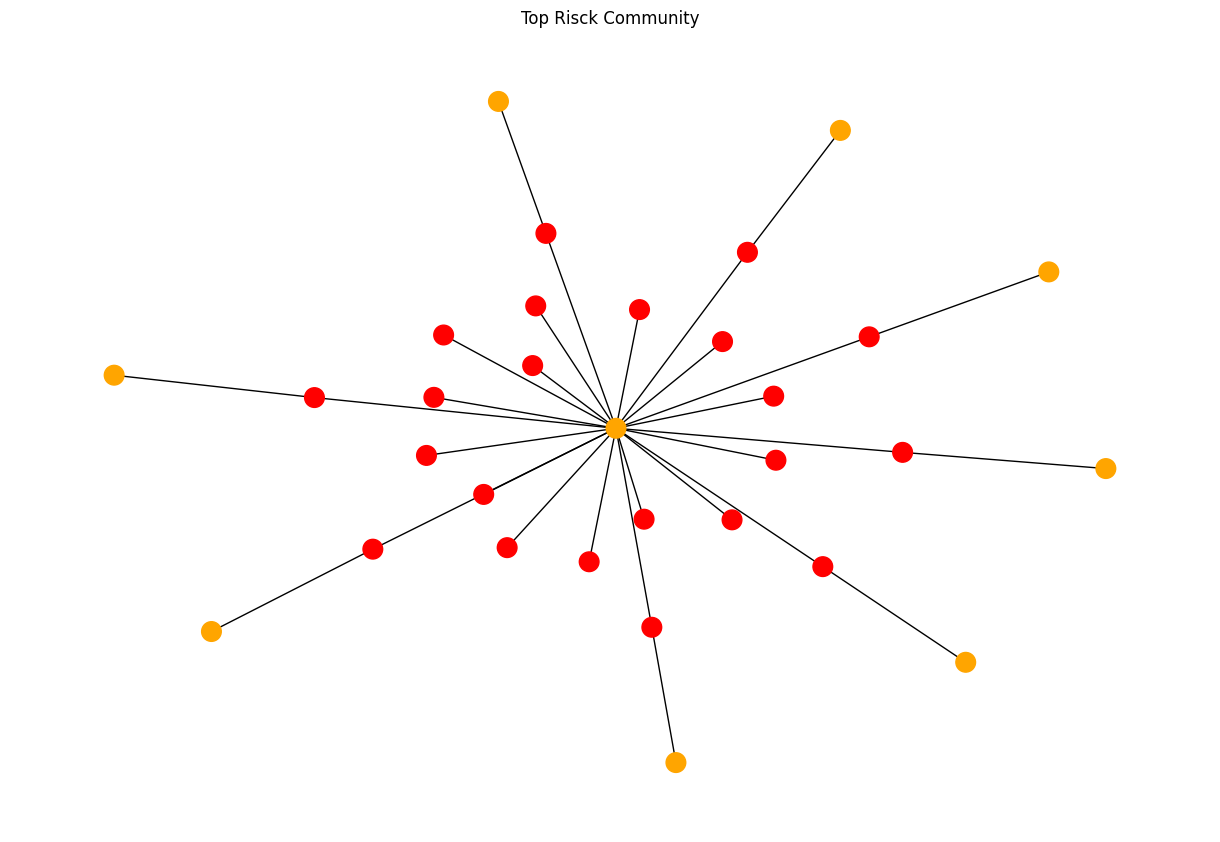

In [146]:
top_community = 2
top_nodes = merged[
    merged["community"] == 2
    ]["txId"]
top_edges = edges_full[
    edges_full["txId1"].isin(top_nodes)
    &
    edges_full["txId2"].isin(top_nodes)
    ]
G_top = nx.from_pandas_edgelist(
    top_edges,
    source = "txId1",
    target = "txId2"
)
node_colors = []
for node in G_top.nodes():
    node_class = merged.loc[
        merged["txId"] == node,
        "class"
    ].values

    if len(node_class) > 0:
        
        if node_class[0] == "1":
            node_colors.append("red")
        elif node_class[0] == "2":
            node_colors.append("green")
        else:
            node_colors.append("orange")
    else:
        node_colors.appen("grey")

plt.figure(figsize=(12,8))
nx.draw(
    G_top,
    node_color = node_colors,
    with_labels = False,
    node_size = 200
)

plt.title("Top Risck Community")
plt.savefig(
    "images/top_risk_community.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [137]:
community_summary[
    community_summary["size"] >= 10
].sort_values(
    by="illegal_ratio",
    ascending=False
)

,community,illegal_ratio,size
2,2.0,0.709677,31
0,0.0,0.580000,50
1,1.0,0.575758,33
4,4.0,0.555556,18
5,5.0,0.555556,18
6,6.0,0.529412,17
3,3.0,0.500000,22


In [138]:
unknown_risk.head(10)

txId1
355092392    8
8695835      7
4732368      7
26532670     6
2842440      6
12776876     6
65263113     5
17124347     5
10773646     5
8373032      5
Name: count, dtype: int64

#### Finding

Several transaction communities exhibit substantially elevated illicit transaction ratios.

The highest-risk communities contain dense clusters of interconnected illicit and unknown transactions, suggesting that illicit cryptocurrency activity tends to concentrate within structurally identifiable network groups rather than appearing randomly across the transaction graph.

## conclusion
This project explored illicit cryptocurrency transaction detection using graph-based network analysis on the Elliptic Bitcoin dataset.

The analysis showed that individual transaction features and temporal patterns alone provide relatively limited explanatory power for identifying illicit activity. Correlation analysis revealed weak relationships between most transaction features and illicit labels.

However, graph network analysis produced substantially stronger findings. Illicit transactions were found to cluster within identifiable network structures, and many unknown transactions were directly connected to illicit nodes.

Community detection further revealed that certain transaction communities exhibit significantly elevated illicit transaction ratios. These findings suggest that illicit cryptocurrency behavior is structurally embedded within transaction networks rather than randomly distributed.

Overall, the project demonstrates that graph-based approaches may provide more effective tools for cryptocurrency risk detection than isolated transaction-level analysis alone.